In [1]:
import pellegrino as p
import pandas as pd
import os
from create_full_information_csv import bookdict

First I reproduced the Koplenig-et-al plots, and I noticed immediately that, although the results were qualitatively similar, the values were quite different. See an example here, and focus on the language “Esk”:

![Koplenig et al Mark](img/koplenig_et_al_mark.png)

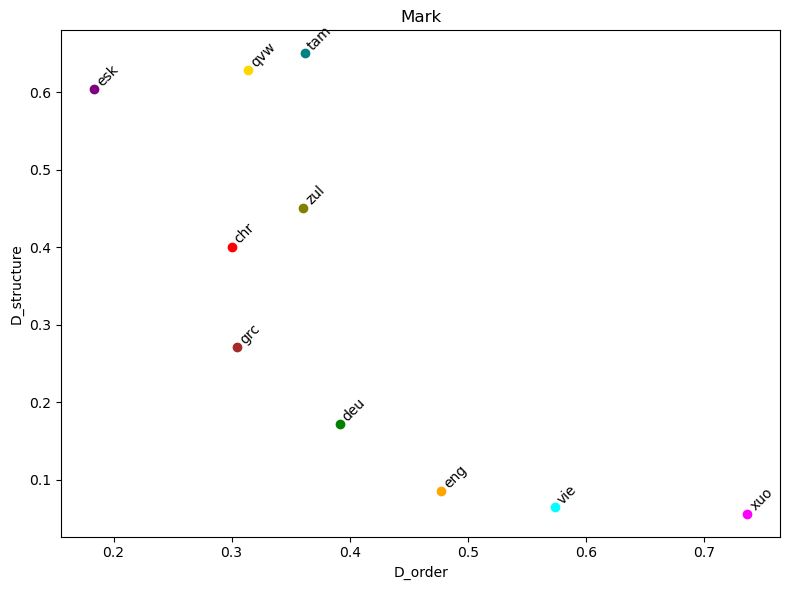

In [2]:
BOOK_NAME = 'Mark'
df_space = pd.read_csv('output/KoplenigEtAlSpace/merged.csv')
df = df_space[df_space['book'] == BOOK_NAME].reset_index(drop=True)
_, bad_bibles = p.exclude_bad_bibles(df_space)
df['language'] = df['bible'].apply(lambda x: x.split('-')[0].strip())
p.run_book(df, True, BOOK_NAME, bad_bibles, overlay_curves=False)

OK, I decided to ignore this point for now, and I overlayed the curves generated by splitting and merging:

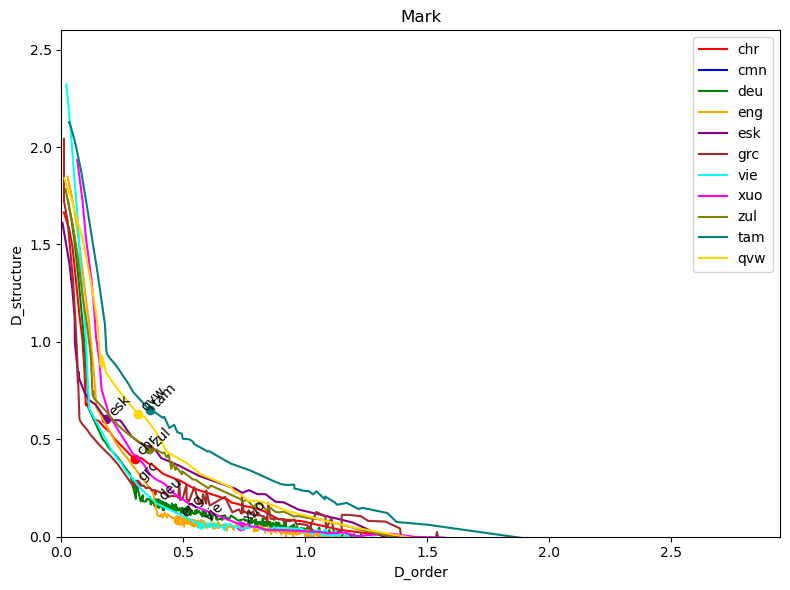

In [3]:
p.run_book(df, True, BOOK_NAME, bad_bibles, overlay_curves=True)

It’s quite hard to make anything of these. There’s a lot of “jumpiness”. This is due to high sampling at some of the locations and low sampling at other locations, mixed with statistical fluctuations in the entropy-calculation procedure. Here’s the same plot again, but with markers to showcase where the entropies are calculated, and only for “grc” (which was shown in brown above):

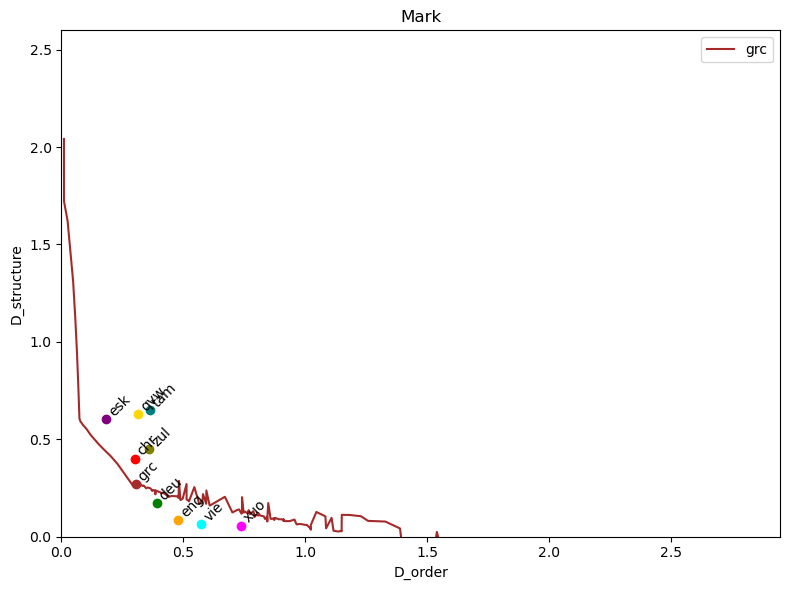

In [4]:
p.run_book(df, True, BOOK_NAME, bad_bibles, overlay_curves=True, select_language='grc')

By the way, there was some issue about calculating things with or without a space. I don’t remember the details, but there were two output files, and the above was generated with the one in the directory “KoplenigEtAlSpace”. Here’s the same plot, but with “KoplenigEtAl”:

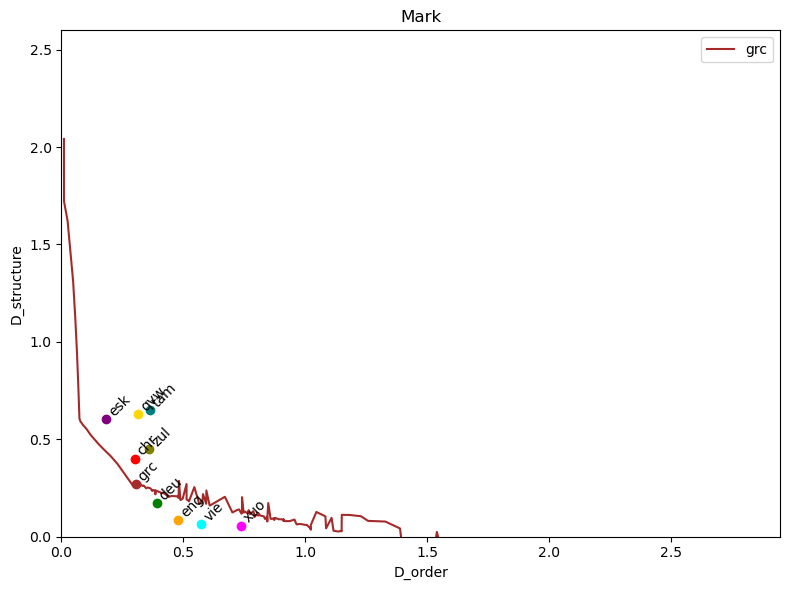

In [5]:
df_other = pd.read_csv('output/KoplenigEtAl/merged.csv')
df_other = df_other[df_other['book'] == BOOK_NAME].reset_index(drop=True)
_, bad_bibles = p.exclude_bad_bibles(df_other)
df_other['language'] = df_other['bible'].apply(lambda x: x.split('-')[0].strip())
p.run_book(df_other, True, 'Mark', bad_bibles, overlay_curves=True, select_language='grc')

So, basically the same. It’s quite puzzling, right? Let’s look at one translation of "grc" separately now.

In [6]:
grc_df = df[df['language'] == 'grc']

In [7]:
grc_df['bible'].unique()

array(['grc-x-bible-tischendorf.txt', 'grc-x-bible-wescotthortVAR1.txt',
       'grc-x-bible-wescotthortVAR2.txt',
       'grc-x-bible-textusreceptusVAR2.txt', 'grc-x-bible-ecumenical.txt',
       'grc-x-bible-combined2005.txt', 'grc-x-bible-byzantine.txt',
       'grc-x-bible-textusreceptusVAR1.txt'], dtype=object)

That's quite a few bibles. Which is longest?

In [8]:
for bible in grc_df['bible'].unique():
    with open(os.path.join('../paralleltext/bibles/corpus/', bible)) as f:
        print(bible, len(f.readlines()))

grc-x-bible-tischendorf.txt 7953
grc-x-bible-wescotthortVAR1.txt 7953
grc-x-bible-wescotthortVAR2.txt 7953
grc-x-bible-textusreceptusVAR2.txt 7969
grc-x-bible-ecumenical.txt 7969
grc-x-bible-combined2005.txt 7951
grc-x-bible-byzantine.txt 7965
grc-x-bible-textusreceptusVAR1.txt 7968


They're all about the same length, so let's just take the first one.

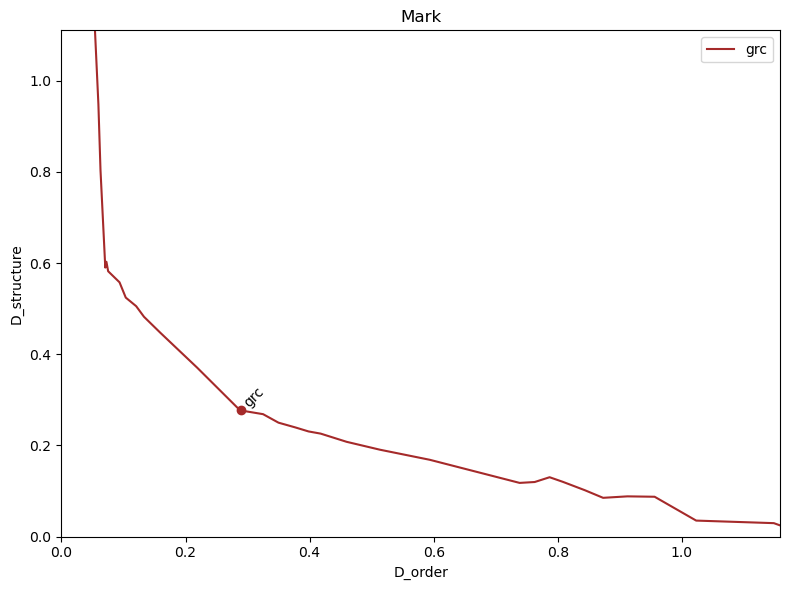

In [9]:
df_space = pd.read_csv('output/KoplenigEtAlSpace/merged.csv')
df_space = df_space[df_space['book'] == BOOK_NAME].reset_index(drop=True)
_, bad_bibles = p.exclude_bad_bibles(df_other)
df_space['language'] = df_space['bible'].apply(lambda x: x.split('-')[0].strip())
df_space = df_space[df_space['bible'] == list(grc_df['bible'].unique())[0]].reset_index(drop=True)
p.run_book(df_space, True, 'Mark', bad_bibles, overlay_curves=True, select_language='grc')

The jumpiness is gone. So, it looks like averaging the curves is not a great idea. Let's repeat this exercise but pick a single translation instead of averaging over translations given a language. First let's see which of the languages have multiple translations:

In [10]:
df_space = pd.read_csv('output/KoplenigEtAlSpace/merged.csv')
df_space['language'] = df_space['bible'].apply(lambda x: x.split('-')[0].strip())
for lang in p.SELECTED_LANGUAGES:
    print(lang, df_space[df_space['language'] == lang]['bible'].nunique())

chr 1
cmn 0
deu 27
eng 34
esk 1
grc 8
vie 7
xuo 1
zul 2
tam 2
qvw 1


Let's programmatically determine which bible has the largest number of verses for the book of Mark for each language:

In [11]:
def max_of_dict(a_dict):
    max_val = -1
    max_k = None
    for k, v in a_dict.items():
        if v > max_val:
            max_val = v
            max_k = k
    return max_k

In [12]:
book_id = {v: k for k, v in bookdict.items()}[BOOK_NAME]
language_bible = {}
for lang in p.SELECTED_LANGUAGES:
    lang_df = df_space[df_space['language'] == lang].reset_index(drop=True)
    n_translations = lang_df['bible'].nunique()
    if n_translations == 0:
        print('WARNING: skipping', lang)
    elif n_translations == 1:
        language_bible[lang] = list(lang_df['bible'].unique())[0]
    else:
        translations = list(lang_df['bible'].unique())
        translation_lines = {}
        for translation in translations:
            with open(os.path.join('../paralleltext/bibles/corpus/', translation)) as f:
                lines = [el.strip() for el in f.readlines()]
            lines = [el for el in lines if el.startswith(str(book_id))]
            translation_lines[translation] = len(lines)
        language_bible[lang] = max_of_dict(translation_lines)

print(language_bible)

{'chr': 'chr-x-bible.txt', 'deu': 'deu-x-bible-bolsinger.txt', 'eng': 'eng-x-bible-kingjames.txt', 'esk': 'esk-x-bible.txt', 'grc': 'grc-x-bible-textusreceptusVAR2.txt', 'vie': 'vie-x-bible-2002.txt', 'xuo': 'xuo-x-bible.txt', 'zul': 'zul-x-bible.txt', 'tam': 'tam-x-bible-easy.txt', 'qvw': 'qvw-x-bible.txt'}


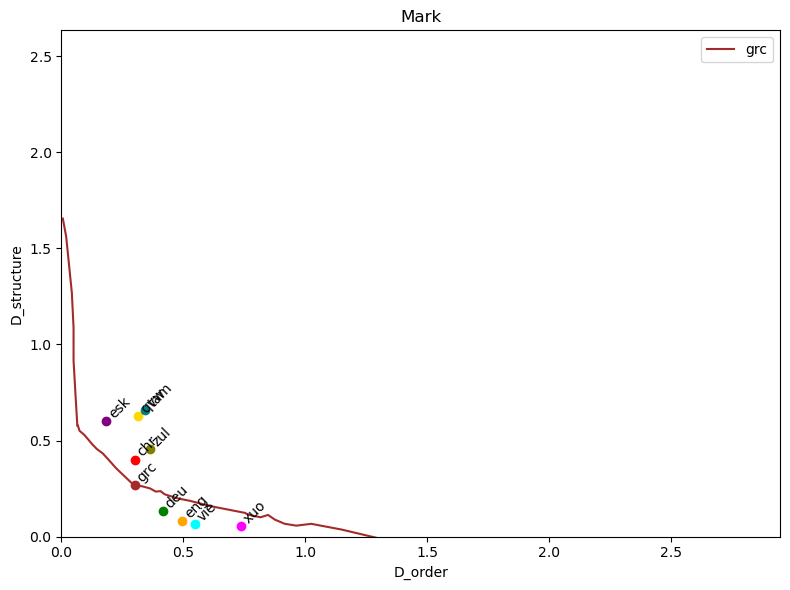

In [13]:
df_space = pd.read_csv('output/KoplenigEtAlSpace/merged.csv')
df_bible = df_space[df_space['bible'].apply(lambda x: x in language_bible.values())].reset_index(drop=True)
df_book = df_bible[df_bible['book'] == BOOK_NAME].reset_index(drop=True)
df_book['language'] = df_book['bible'].apply(lambda x: x.split('-')[0].strip())
p.run_book(df_book, True, 'Mark', bad_bibles, overlay_curves=True, select_language='grc')

This looks better. Let's now put all the language curves there again.

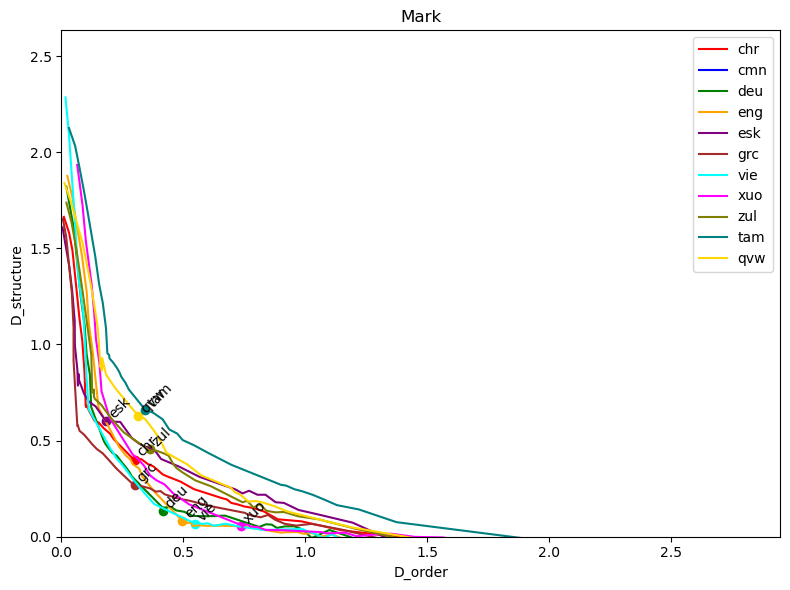

In [14]:
p.run_book(df_book, True, 'Mark', bad_bibles, overlay_curves=True)

This does not say much. What if we try smoothing the curves?

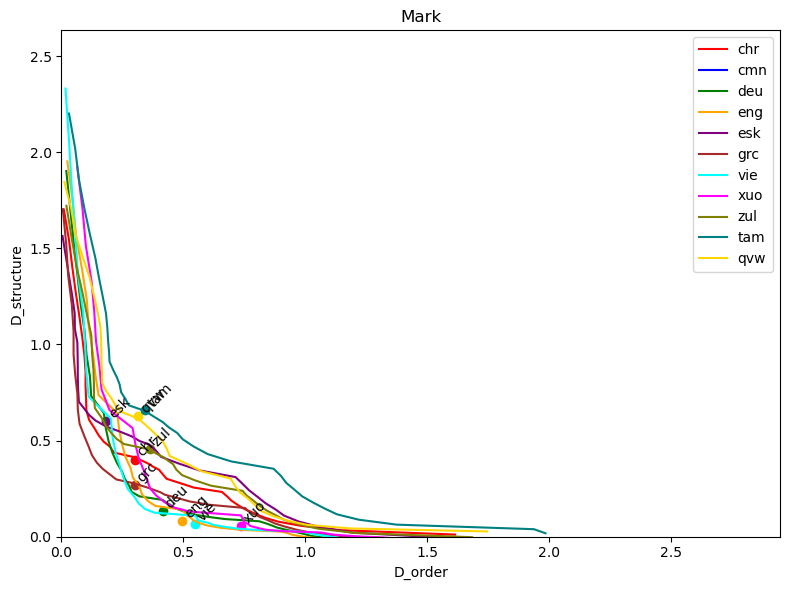

In [15]:
p.run_book(df_book, True, 'Mark', bad_bibles, overlay_curves=True, smooth_curves=True)

The smoothing did not produce easily interpretable results.